In [227]:
import numpy as np

EXP_POWER_UTILITY = 10**5
eta = np.float64(10.0)
d_max = 100.0


receiver_coordinates = (0.0, 0.0, 0.0)

### CHANNEL GAIN CODE - OUTDOOR

In [2]:
import numpy as np
import math

c = 3 * 10**8                                    # propagation velocity in the free space [m/s]
h_BS = 3.5                                       # antenna height of the base station [m]
h_UT = 3.5                                       # antenna height of the user terminal [m]
h_E = 1                                          # effective environment height [m]
h_prime_BS = h_BS - h_E                          # effective antenna height of the base station [m]
h_prime_UT = h_UT - h_E                          # effective antenna height of the user terminal [m]

def get_distance2D(p1, p2):
    d = np.sqrt((p1[0] - p2[0]) ** 2 + (p1[1] - p2[1]) ** 2)
    return d

def get_distance3D(p1, p2):
    d = np.sqrt((p1[0] - p2[0]) ** 2 + (p1[1] - p2[1]) ** 2 + (p1[2] - p2[2]) ** 2)
    return d

def get_PL_LOS(p1, p2, f_c):
    d_2D = get_distance2D(p1, p2)
    d_3D = get_distance3D(p1, p2)
    d_BP = (4 * h_prime_BS * h_prime_UT * f_c) / c
    if (d_2D < 10):
        if (d_3D >= 1) and (d_3D <= 150):
            PL_LOS = 32.4 + 17.3*math.log10(d_3D) + 20*math.log10(f_c * 10**(-9))
    else:
        if (d_2D >= 10) and (d_2D <= d_BP):
            PL_LOS = 32.4 + 21*math.log10(d_3D) + 20*math.log10(f_c * 10**(-9))
        elif (d_2D >= d_BP) and (d_2D <= 5 * 10**3):
            PL_LOS = 32.4 + 40*math.log10(d_3D) + 20*math.log10(f_c * 10**(-9)) - 9.5*math.log10((d_BP)**2 + (p1[2] - p2[2])**2)
    return PL_LOS

def get_PL_NLOS(p1, p2, f_c):
    d_2D = get_distance2D(p1, p2)
    d_3D = get_distance3D(p1, p2)
    if (d_2D < 10):
        if (d_3D >= 1) and (d_3D <= 150):
            PL_prime_NLOS = 17.3 + 38.3*math.log10(d_3D) + 24.9*math.log10(f_c * 10**(-9))
    else:
        if (d_2D >= 10) and (d_2D <= 5 * 10**3):
            PL_prime_NLOS = 22.4 + 35.3*math.log10(d_3D) + 21.3*math.log10(f_c * 10**(-9)) - 0.3*(p2[2] - 1.5)
    PL_NLOS = max(get_PL_LOS(p1, p2, f_c), PL_prime_NLOS)
    return PL_NLOS

#this function gives the probability that how much of the transmission is in Line of Sight
def get_Pr(p1, p2):
    d_2D = get_distance2D(p1, p2)
    if (d_2D < 10):
        if (d_2D <= 1.2):
            pr_LOS = 1
        elif (d_2D > 1.2) and (d_2D < 6.5):
            pr_LOS = math.exp(-(d_2D - 1.2)/4.7)
        elif (d_2D >= 6.5):
            pr_LOS = math.exp(-(d_2D - 6.5)/32.6) * 0.32
    else:
        if d_2D <= 18:
            pr_LOS = 1
        elif d_2D > 18:
            pr_LOS = (18/d_2D) + (math.exp(-d_2D/36) * (1 - (18/d_2D)))
    return pr_LOS

def get_PL(p1, p2, f_c):
    PL = get_Pr(p1, p2) * get_PL_LOS(p1, p2, f_c) + (1 - get_Pr(p1, p2)) * get_PL_NLOS(p1, p2, f_c)
    return PL

def get_channel_gain(p1, p2, f_c):
    g = 1 / 10**(get_PL(p1, p2, f_c) / 10)
    return np.float64(g)

### CHANNEL GAIN CODE - INHOUSE(OPEN/MIXED)

In [3]:
import numpy as np
import math

def get_distance2D(p1, p2):
    return np.hypot(p1[0]-p2[0], p1[1]-p2[1])

def get_distance3D(p1, p2):
    return np.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2 + (p1[2]-p2[2])**2)

# -------- 38.901 InH (Indoor-Office) PATH LOSS --------
def get_PL_LOS_InH(p1, p2, f_c):
    """
    3GPP TR 38.901 InH Office LOS:
      PL_LOS = 32.4 + 17.3*log10(d_3D) + 20*log10(fc_GHz), for 1 m <= d_3D <= 150 m
    """
    d_3D = get_distance3D(p1, p2)
    if d_3D < 1:  # spec validity starts at 1 m
        d_3D = 1.0
    if d_3D > 150:
        d_3D = 150.0
    fc_GHz = f_c * 1e-9
    PL_LOS = 32.4 + 17.3*math.log10(d_3D) + 20.0*math.log10(fc_GHz)
    return PL_LOS

def get_PL_NLOS_InH(p1, p2, f_c):
    """
    3GPP TR 38.901 InH Office NLOS (use max with LOS):
      PL'_NLOS = 38.3*log10(d_3D) + 17.30*log10(fc_GHz) + 24.9, for 1 m <= d_3D <= 150 m
      PL_NLOS = max(PL_LOS, PL'_NLOS)
    """
    d_3D = get_distance3D(p1, p2)
    if d_3D < 1:
        d_3D = 1.0
    if d_3D > 150:
        d_3D = 150.0
    fc_GHz = f_c * 1e-9
    PL_LOS = get_PL_LOS_InH(p1, p2, f_c)
    PLp_NLOS = 38.3*math.log10(d_3D) + 17.30*math.log10(fc_GHz) + 24.9
    return max(PL_LOS, PLp_NLOS)

# -------- LOS PROBABILITY (choose 'open' or 'mixed') --------
def get_Pr_InH(p1, p2, office_type='open'):
    """
    InH LOS probability from TR 38.901 Table 7.4.2-1.
    office_type: 'open' (default) or 'mixed'
    Uses d_in-2D (horizontal) in meters.
    """
    d = get_distance2D(p1, p2)
    if office_type == 'mixed':
        if d <= 1.2:
            return 1.0
        elif d < 6.5:
            return math.exp(-(d - 1.2)/4.7)
        else:
            return 0.32 * math.exp(-(d - 6.5)/32.6)
    else:  # 'open' office
        if d <= 5.0:
            return 1.0
        elif d < 49.0:
            return math.exp(-(d - 5.0)/70.0)
        else:
            return 0.54 * math.exp(-(d - 49.0)/211.7)

def get_PL_InH(p1, p2, f_c, office_type='open'):
    pr = get_Pr_InH(p1, p2, office_type)
    PL_los = get_PL_LOS_InH(p1, p2, f_c)
    PL_nlos = get_PL_NLOS_InH(p1, p2, f_c)
    return pr*PL_los + (1.0 - pr)*PL_nlos

def get_channel_gain_InH(p1, p2, f_c, office_type='open'):
    """
    Returns linear power gain g = 10^(-PL/10)
    """
    PL = get_PL_InH(p1, p2, f_c, office_type)
    return 10.0**(-PL/10.0)


### NON EXHAUSTIVE C BOUND

In [ ]:
def compute_c_bounds(h, P_max, eta):
    N = len(h)
    sum1 = np.sum(h * np.sqrt(P_max) / np.sqrt(eta))

    print("For number of transmitters: ",N)
    c_lower = 0
    for i in range(N):
        me = h[i] * np.sqrt(P_max[i]) / np.sqrt(eta)
        other = sum1 - me
        c_low = (np.sqrt(eta) / (2 * np.sqrt(P_max[i]) * np.abs(h[i]))) * np.exp(EXP_POWER_UTILITY * other)

        c_lower = max(c_lower, c_low)

    return c_lower

### EXHAUSTIVE C BOUND

In [ ]:
import numpy as np
import itertools

def compute_c_bounds_exhaustive(h, P_max, eta, step=0.1):
    """
    Compute c bounds by exhaustively searching all combinations of power values.
    We create for step=0.1 all combinations of P values between 0 and P_max. And for all of them calculate lower bound of c.
    We take max of lower bounds
    for N=100 it it 10^100 combinations so actually it is better ro aproximate using P_max
    """
    N = len(h)

    # Create power value ranges for each user
    power_ranges = []
    for i in range(N):
        # Generate power values from step to P_max[i] with step size
        power_values = np.arange(step, P_max[i] + step, step)
        power_ranges.append(power_values)

    c_lower = 0
    total_combinations = 1
    for i in range(N):
        total_combinations *= len(power_ranges[i])

    print(f"Total combinations to check: {total_combinations}")

    # Use itertools.product to generate all combinations
    for P_curr in itertools.product(*power_ranges):
        P_curr = np.array(P_curr)

        # Calculate the sum for this combination
        sum_val = np.sum(h * np.sqrt(P_curr) / np.sqrt(eta))

        # Calculate lower bound for each user
        for n in range(N):
            me = h[n] * np.sqrt(P_curr[n]) / np.sqrt(eta)
            other = sum_val - me
            low = (np.sqrt(eta) / (2 * np.sqrt(P_max[n]) * np.abs(h[n]))) * np.exp(EXP_POWER_UTILITY * other)
            c_lower = max(c_lower, low)

    return c_lower

### PLOT TO SEE RECEIVER TRANSMITTERS ARRANGEMENT

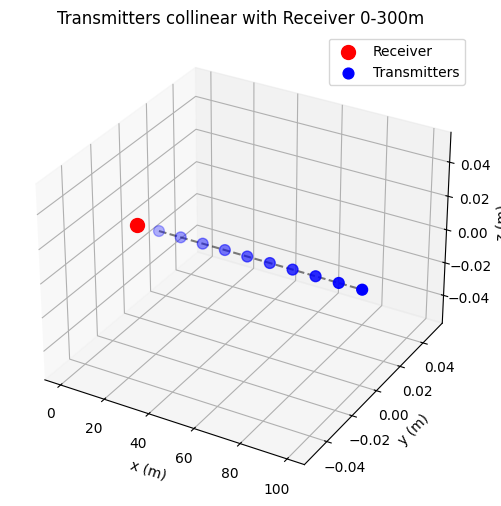

In [121]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Parameters
N = 10
d_max = 100.0
max_iteration = 10
receiver_coordinates = (0.0, 0.0, 0.0)

# Transmitters equally spaced along x-axis between 0 and 300 m
x_positions = np.linspace(d_max/N, d_max, N)  # start after 0
transmitter_coordinates = [(x, 0.0, 0.0) for x in x_positions]


# ---- Plot 3D ----
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

# Receiver
ax.scatter(*receiver_coordinates, c='red', s=100, label='Receiver')

# Transmitters
tx = np.array(transmitter_coordinates)
ax.scatter(tx[:,0], tx[:,1], tx[:,2], c='blue', s=60, label='Transmitters')

# Connect them along the line
ax.plot(tx[:,0], tx[:,1], tx[:,2], 'k--', alpha=0.5)

# Labels
ax.set_title("Transmitters collinear with Receiver 0-300m")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_zlabel("z (m)")
ax.legend()
ax.grid(True)

plt.show()


### TESTING C BOUND

Finding c for 100 users to use it everywhere

In [159]:
N = 100

x_positions = np.linspace(d_max/N, d_max, N)
transmitter_coordinates = [(x, 0.0, 0.0) for x in x_positions]
h = np.zeros(N)
for i in range(N):
    h[i] = get_channel_gain(transmitter_coordinates[i],receiver_coordinates,2405*10**6)

P_max = np.ones(N)
c_lower = compute_c_bounds(h, P_max, eta)
print(c_lower)

For number of transmitters:  100
25803188010.161278


### UTILITY AND OPTIMAL POWER FUNCTIONS

In [140]:
import numpy as np
import numpy.typing as npt

def utility_vector(P: npt.NDArray[np.float64], h: npt.NDArray[np.float64], c: np.float64, eta: np.float64):
    utilities = np.zeros(len(P))
    # sum1 = np.sum(h * np.sqrt(P) / np.sqrt(eta))
    sum1 = 0 # to calculate time accurately without numpy shinanigans
    for i in range(len(P)):
        sum1 += h[i] * np.sqrt(P[i]) / np.sqrt(eta)

    for i in range(len(P)):
        me = h[i] * np.sqrt(P[i]) / np.sqrt(eta)
        other = sum1 - me
        utilities[i] = me * np.exp(EXP_POWER_UTILITY *other) - c * np.power(me, 2)
    return utilities


def closed_form_p_star(h: npt.NDArray[np.float64], c: np.float64, eta: np.float64, P_max: npt.NDArray[np.float64], P: npt.NDArray[np.float64]):
    # sum1 = np.sum(h * np.sqrt(P)/np.sqrt(eta))
    sum1 = 0 # to calculate time accurately without numpy shinanigans
    for i in range(len(P)):
        sum1 += h[i] * np.sqrt(P[i]) / np.sqrt(eta)
    
    P_star = np.zeros(len(P))
    for i in range(len(P)):
        me = h[i] * np.sqrt(P[i]) / np.sqrt(eta)
        other = sum1 - me
        P_star[i] = eta * np.exp(2* EXP_POWER_UTILITY *other)/ (4 * np.power(c, 2) * np.power(h[i], 2))

    P_star = np.clip(P_star, 0, P_max)
    return P_star

### ADAPTIVE BEST RESPONSE FUNCTION

In [160]:
#Adaptive Best Response Function
import time
import numpy as np
import numpy.typing as npt
import pandas as pd

def adaptive_best_response(
    h: npt.NDArray[np.float64],
    eta: np.float64,
    epsilon: np.float64,
    P_max: npt.NDArray[np.float64],
    max_iteration: int = 1000
):
    # print('Executing adaptive best response')
    # Compute feasible bounds for c
    #c = compute_c_bounds(h,P_max, eta)
    c = np.float64(8022291587.0)

    history_util = {}
    history_power = {}

    convergence = 0
    iteration = 0

    brd_start = time.time()
    P_current = np.random.uniform(0, P_max, len(h))
    utility_history = [utility_vector(P_current, h, c, eta)]
    power_history = [P_current.copy()]

    while convergence == 0:
        iteration += 1

        P_new = closed_form_p_star(h, c, eta, P_max, P_current)
        utility_history.append(utility_vector(P_new, h, c, eta))
        power_history.append(P_new.copy())
        
        all_satisfy_epsilon = 1
        for i in range(len(P_current)): # to calculate time accurately
            if np.abs(utility_history[-1][i] - utility_history[-2][i]) >= epsilon:
                all_satisfy_epsilon = 0

        if iteration == max_iteration or all_satisfy_epsilon:
            convergence = 1
        else:
            P_current = P_new

    # End timing
    brd_time = time.time() - brd_start

    history_util[c] = np.array(utility_history)
    history_power[c] = np.array(power_history)

    df = pd.DataFrame({
        "Node": np.arange(1, len(h) + 1),
        "Final Power P*": P_new,
        "Final Utility": utility_history[-1],
        "Channel Gain h": h,
    })
    return c, history_util, history_power, df, brd_time, iteration

In [172]:
epsilon = np.float64(1e-15)

N = 10
P_max = np.ones(N)
x_positions = np.linspace(d_max/N, d_max, N)
transmitter_coordinates = [(np.float64(x), 0.0, 0.0) for x in x_positions]

h = np.zeros(N)
for i in range(N):
    h[i] = get_channel_gain(transmitter_coordinates[i],receiver_coordinates,2405*10**6)

c_star, utility_histories, power_histories, df, brd_time, iteration = adaptive_best_response(
        h, eta, epsilon, P_max, max_iteration
    )

print(f"Took {iteration} itr")
if c_star is not None:
        print("\n" + "="*80)
        print("FINAL RESULTS SUMMARY")
        print("="*80)
        pd.set_option('display.float_format', '{:.6e}'.format)
        print(df.to_string(index=False))
        print("="*80)

Took 3 itr

FINAL RESULTS SUMMARY
 Node  Final Power P*  Final Utility  Channel Gain h
    1    6.220885e-08   3.116666e-11    7.902597e-07
    2    1.379091e-06   3.116666e-11    1.678416e-07
    3    2.206154e-05   3.116666e-11    4.196411e-08
    4    2.212283e-04   3.116666e-11    1.325182e-08
    5    1.562784e-03   3.116666e-11    4.985932e-09
    6    8.343810e-03   3.116666e-11    2.157813e-09
    7    3.545615e-02   3.116666e-11    1.046767e-09
    8    1.248951e-01   3.116666e-11    5.577289e-10
    9    3.768262e-01   3.116666e-11    3.210889e-10
   10    1.000000e+00   3.116666e-11    1.971038e-10


### PLOT 1 - BR ITERATIONS VS POWER

In [169]:
power_histories[c_star]

array([[9.02364339e-01, 5.57602185e-01, 2.52315355e-01, 2.33561921e-01,
        3.86843094e-01, 9.54110092e-01, 4.43266910e-01, 8.35684961e-01,
        7.31965407e-01, 5.67768415e-02],
       [6.28327266e-08, 1.44911665e-06, 2.33351116e-05, 2.34216732e-04,
        1.65488190e-03, 8.83607930e-03, 3.75513528e-02, 1.32277094e-01,
        3.99104550e-01, 1.00000000e+00],
       [6.22090264e-08, 1.37909409e-06, 2.20615935e-05, 2.21228889e-04,
        1.56278846e-03, 8.34383119e-03, 3.54562451e-02, 1.24895462e-01,
        3.76827193e-01, 1.00000000e+00],
       [6.22088496e-08, 1.37909051e-06, 2.20615373e-05, 2.21228326e-04,
        1.56278449e-03, 8.34380998e-03, 3.54561550e-02, 1.24895145e-01,
        3.76826235e-01, 1.00000000e+00]])

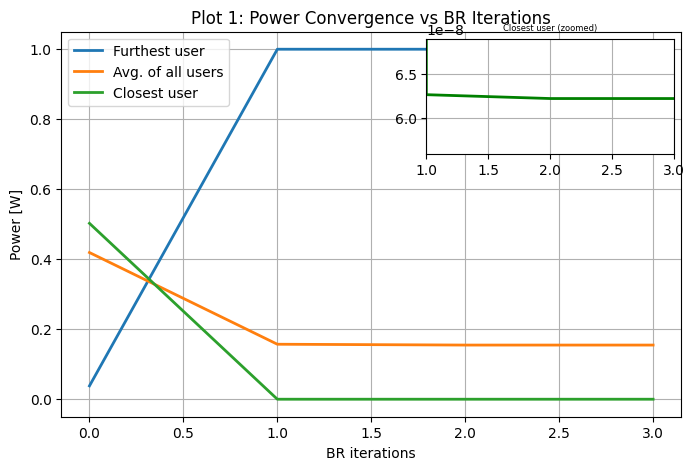

In [177]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

if df is not None:
    power_history = power_histories[c_star]  # shape = (iterations, N)
    closest_idx = np.argmax(h)
    furthest_idx = np.argmin(h)

    closest_user = power_history[:, closest_idx]
    furthest_user = power_history[:, furthest_idx]
    avg_users = np.mean(power_history, axis=1)
    iterations = np.arange(0, power_history.shape[0])

    # Main plot
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(iterations, furthest_user, label="Furthest user", linewidth=2)
    ax.plot(iterations, avg_users, label="Avg. of all users", linewidth=2)
    ax.plot(iterations, closest_user, label="Closest user", linewidth=2)

    ax.set_xlabel("BR iterations")
    ax.set_ylabel("Power [W]")
    # ax.set_yscale('log')
    # ax.set_xticks(np.arange(0, iteration+1, 1))
    ax.set_title("Plot 1: Power Convergence vs BR Iterations")
    ax.legend()
    ax.grid(True)

    # Inset focusing on the 'flat' part of closest user (iterations 2 → 4)
    axins = inset_axes(ax, width="40%", height="30%", loc="upper right")  # moved here
    axins.plot(iterations, closest_user, color="green", linewidth=2)
    axins.set_title("Closest user (zoomed)", fontsize=6)

    # Zoom on iterations 2–4 and y-range around the small values
    axins.set_xlim(1, 3)
    # axins.set_xticks(np.arange(1, iteration+1, 1))
    axins.set_ylim(min(closest_user[1:]) * 0.9, max(closest_user[1:]) * 1.1)
    # axins.set_yscale('log')
    axins.grid(True)

    plt.show()


C:\Users\asabyrb1\AppData\Local\Temp\ipykernel_32548\3150651529.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


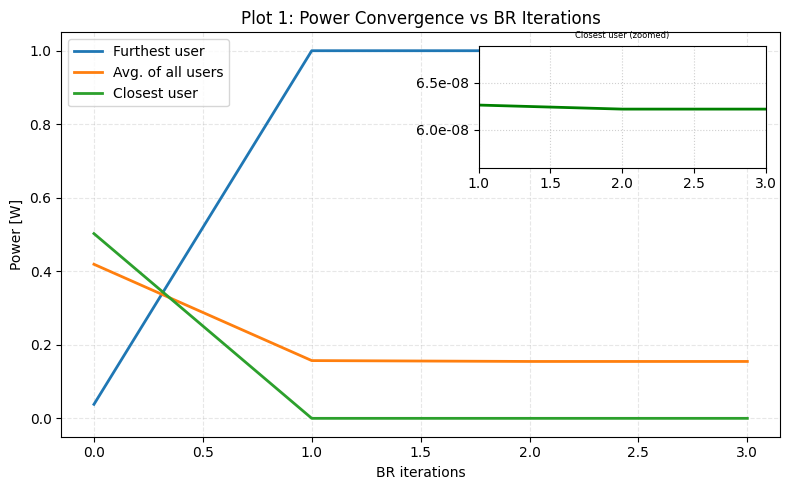

In [182]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import FormatStrFormatter

if df is not None:
    power_history = power_histories[c_star]  # shape = (iterations, N)
    closest_idx = np.argmax(h)
    furthest_idx = np.argmin(h)

    closest_user = power_history[:, closest_idx]
    furthest_user = power_history[:, furthest_idx]
    avg_users = np.mean(power_history, axis=1)
    iterations = np.arange(0, power_history.shape[0])

    # --- Main plot ---
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(iterations, furthest_user, label="Furthest user", linewidth=2)
    ax.plot(iterations, avg_users, label="Avg. of all users", linewidth=2)
    ax.plot(iterations, closest_user, label="Closest user", linewidth=2)

    ax.set_xlabel("BR iterations")
    ax.set_ylabel("Power [W]")
    ax.set_title("Plot 1: Power Convergence vs BR Iterations")
    ax.legend()
    ax.grid(True, which="both", linestyle="--", alpha=0.3)

    # --- Inset focusing on the 'flat' part of closest user (iterations 2 → 4) ---
    axins = inset_axes(ax, width="40%", height="30%", loc="upper right", borderpad=1.0)
    axins.plot(iterations, closest_user, color="green", linewidth=2)

    # Lock the view to your requested ranges
    axins.set_xlim(1, 3)
    axins.set_ylim(min(closest_user[1:]) * 0.9, max(closest_user[1:]) * 1.1)

    # Scientific notation for tiny values
    axins.yaxis.set_major_formatter(FormatStrFormatter('%.1e'))

    axins.set_title("Closest user (zoomed)", fontsize=6)
    axins.grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()


### PLOT 2- BR ITERATIONS VS UTILITY

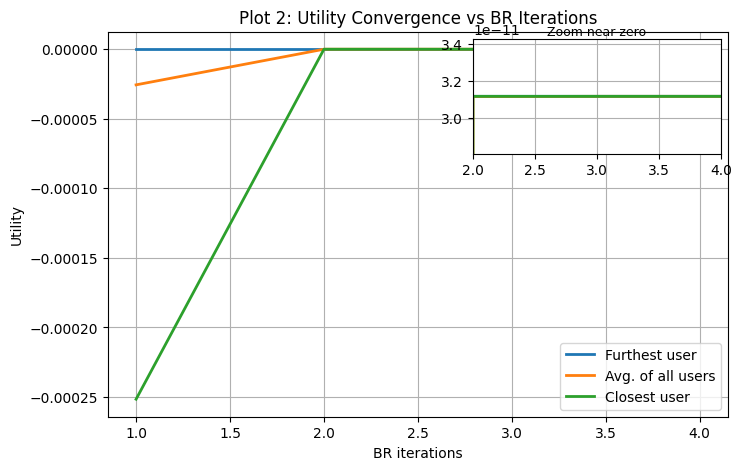

In [183]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Pick the utility history for the chosen c
util_history = utility_histories[c_star]  # shape = (iterations, N)

closest_idx = np.argmax(h)
furthest_idx = np.argmin(h)

closest_util = util_history[:, closest_idx]
furthest_util = util_history[:, furthest_idx]
avg_util = np.mean(util_history, axis=1)

iterations = np.arange(1, util_history.shape[0] + 1)

# Main plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(iterations, furthest_util, label="Furthest user", linewidth=2)
ax.plot(iterations, avg_util, label="Avg. of all users", linewidth=2)
ax.plot(iterations, closest_util, label="Closest user", linewidth=2)

ax.set_xlabel("BR iterations")
ax.set_ylabel("Utility")
ax.set_title("Plot 2: Utility Convergence vs BR Iterations")
ax.legend()
ax.grid(True)

# Inset: zoom only on the flat region (iterations 2 → 4)
axins = inset_axes(ax, width="40%", height="30%", loc="upper right")
axins.plot(iterations, furthest_util, linewidth=2)
axins.plot(iterations, avg_util, linewidth=2)
axins.plot(iterations, closest_util, linewidth=2)
axins.set_title("Zoom near zero", fontsize=9, pad=2)

# Focus on iterations 2–4
axins.set_xlim(2, 4)

# Tighten y-limits just for this region
flat_values = np.concatenate([
    furthest_util[1:],  # from iteration 2
    avg_util[1:],
    closest_util[1:]
])
axins.set_ylim(min(flat_values) * 0.9, max(flat_values) * 1.1)
axins.grid(True)

plt.show()


### PLOT 3- OPTIMAL POWER ALLOCATION PER USER

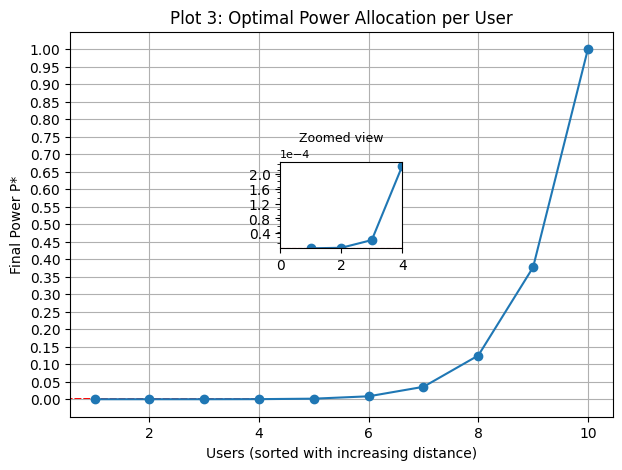

In [184]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle

# Example: assuming df is already defined
users = range(1, len(df) + 1)
power = df["Final Power P*"].values

plt.figure(figsize=(7,5))
plt.plot(users, power, marker='o')
plt.xlabel("Users (sorted with increasing distance)")
plt.ylabel("Final Power P*")
plt.title("Plot 3: Optimal Power Allocation per User")
plt.grid(True)

# Set y-axis ticks at intervals of 0.05
y_min, y_max = 0, 1.05
plt.yticks(np.arange(y_min, y_max, 0.05))

# --- Inset zoom ---
ax = plt.gca()
axins = inset_axes(
    ax, width="45%", height="45%",
    bbox_to_anchor=(0.25, 0.3, 0.5, 0.5),
    bbox_transform=ax.transAxes, loc="center"
)

axins.plot(users, power, marker='o')

# Focus zoom on users 0 → 4
axins.set_xlim(0, 4)

# Tight y-range based on first 4 users
pmin, pmax = min(power[:4]), max(power[:4])
axins.set_ylim(pmin * 0.95, pmax * 1.05)

# Add horizontal line at 0 for reference
axins.axhline(0, color="red", linestyle="--", linewidth=0.8)

# Force y-axis scientific notation (1e-6)
axins.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axins.yaxis.get_offset_text().set_size(8)   # smaller font for "1e-6"

# Increase resolution of y-axis
axins.yaxis.set_major_locator(plt.MaxNLocator(6))
axins.yaxis.set_minor_locator(plt.MaxNLocator(20))

axins.set_title("Zoomed view", fontsize=9)

# Highlight region in main plot (optional red box)
rect = Rectangle((0, pmin * 0.95),
                 4, (pmax * 1.05) - (pmin * 0.95),
                 linewidth=1.2, edgecolor='red', linestyle='--', fill=False)
ax.add_patch(rect)

plt.show()


### PLOT 4: FINAL UTILITY PER USER

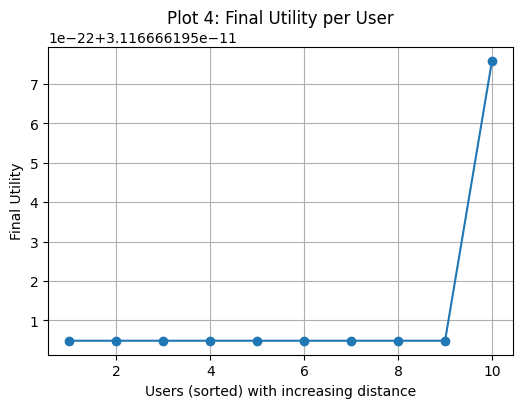

In [185]:
import matplotlib.pyplot as plt

# Sort users by index (or by distance if you have that column)
users = range(1, len(df) + 1)
power = df["Final Utility"].values

plt.figure(figsize=(6,4))
plt.plot(users, power, marker='o')
plt.xlabel("Users (sorted) with increasing distance")
plt.ylabel("Final Utility")
plt.title("Plot 4: Final Utility per User")
plt.grid(True)
plt.show()

# SCALABILITY

### PLOT 5: MEAN POWER VS NUMBER OF USERS

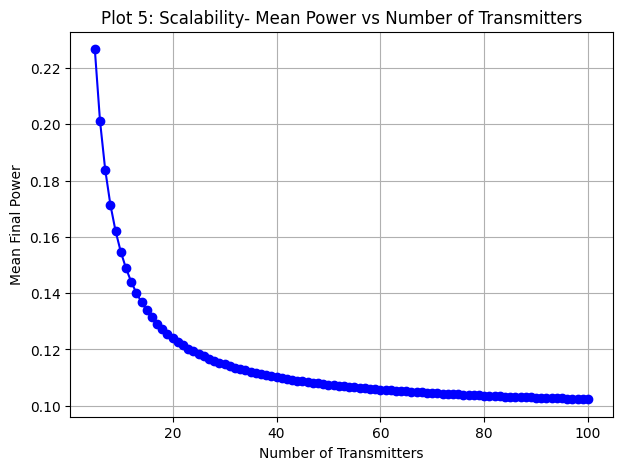

In [ ]:
results = []

# Loop over number of transmitters
for i in range(5, 101):   # 1 to 100
    x_positions = np.linspace(d_max/i, d_max, i)
    transmitter_coordinates = [(x, 0.0, 0.0) for x in x_positions]
    h = np.zeros(i)
    for j in range(0,i):
        h[j] = get_channel_gain(transmitter_coordinates[j],receiver_coordinates,2405*10**6)

    P = np.random.uniform(0.1, 1.0, i)
    P_max = np.ones(i)

    # Run your algorithm
    *_, df, _, _ = adaptive_best_response(h, eta, epsilon, P_max, max_iteration)

    # Extract final powers (example: mean power across transmitters)
    if df is not None:
        mean_power = df['Final Power P*'].mean()

        # Save (n, mean_power) pair
        results.append((i, mean_power))

# Convert to DataFrame for plotting
scalability_df = pd.DataFrame(results, columns=['Users', 'Mean Power'])

plt.figure(figsize=(7,5))
plt.plot(scalability_df['Users'], scalability_df['Mean Power'], marker='o', color='blue')
plt.xlabel("Number of Transmitters")
plt.ylabel("Mean Final Power")
plt.title("Plot 5: Scalability- Mean Power vs Number of Transmitters")
plt.grid(True)
plt.show()

### PLOT 6: Mean Utility vs Number of Users

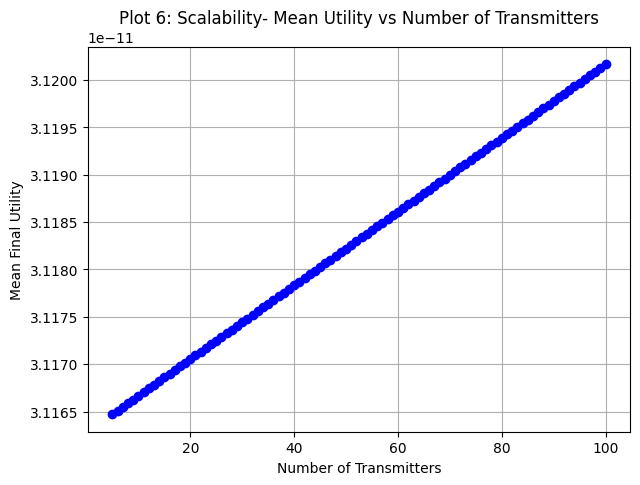

In [203]:
results = []

for i in range(5, 101):
    x_positions = np.linspace(d_max/i, d_max, i)
    transmitter_coordinates = [(x, 0.0, 0.0) for x in x_positions]
    h = np.zeros(i)

    for j in range(0,i):
        h[j] = get_channel_gain(transmitter_coordinates[j],receiver_coordinates,2405*10**6)

    P = np.random.uniform(0.1, 1.0, i)
    P_max = np.ones(i)

    # Run your algorithm
    *_, df, _, _ = adaptive_best_response( h, eta, epsilon, P_max, max_iteration)

    if df is not None:
        mean_utility = df['Final Utility'].mean()
        results.append((i, mean_utility))


# Convert to DataFrame for plotting
scalability_df1 = pd.DataFrame(results, columns=['Users', 'Mean Utility'])

plt.figure(figsize=(7,5))
plt.plot(scalability_df1['Users'], scalability_df1['Mean Utility'], marker='o', color='blue')
plt.xlabel("Number of Transmitters")
plt.ylabel("Mean Final Utility")
plt.title("Plot 6: Scalability- Mean Utility vs Number of Transmitters")
plt.grid(True)
plt.show()

### Complexity

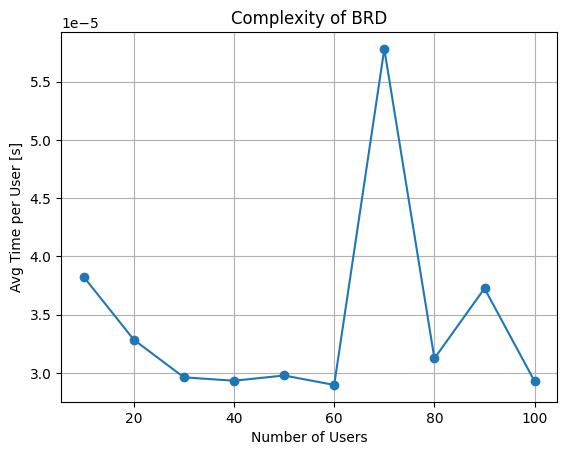

In [218]:
results = []

for i in range(10, 110, 10):  # test with 10,20,...,100 users
    P = np.random.uniform(0.1, 1.0, i)
    P_max = np.ones(i)

    x_positions = np.linspace(d_max/i, d_max, i)
    transmitter_coordinates = [(x, 0.0, 0.0) for x in x_positions]
    h = np.zeros(i)
    
    for j in range(0,i):
        h[j] = get_channel_gain(transmitter_coordinates[j],receiver_coordinates,2405*10**6)

    brd_result = adaptive_best_response(h, eta, epsilon, P_max, max_iteration)

    if brd_result is not None:
        _, _, _, df, brd_time, _ = brd_result
        if df is not None and brd_time is not None:
            avg_time_per_user = brd_time / i
            results.append((i, avg_time_per_user))

# Plot
if results:  # Only plot if there are results
    scalability_df = pd.DataFrame(results, columns=['Users', 'Avg BRD Time'])
    plt.plot(scalability_df['Users'], scalability_df['Avg BRD Time'], marker='o')
    plt.xlabel("Number of Users")
    plt.ylabel("Avg Time per User [s]")
    plt.title("Complexity of BRD")
    plt.grid(True)
    plt.show()
else:
    print("No data collected for plotting.")

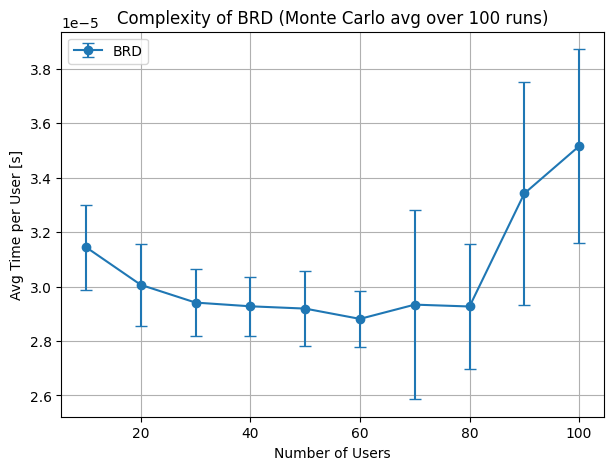

In [224]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# Monte Carlo runs
MC_runs = 100 # you can try 1000 if time allows
results = []

for i in range(10, 110, 10):  # users = 5, 10, 15, ..., 100
    times = []
    for mc in range(MC_runs):
        P = np.random.uniform(0.1, 1.0, i)
        P_max = np.ones(i)

        x_positions = np.linspace(d_max/i, d_max, i)
        transmitter_coordinates = [(x, 0.0, 0.0) for x in x_positions]
        h = [get_channel_gain(transmitter_coordinates[j], receiver_coordinates, 2405e6)
             for j in range(i)]

        # Run BRD
        _, _, _, df, brd_time, _ = adaptive_best_response(
            h, eta, epsilon, P_max, max_iteration
        )

        if brd_time is not None:
            avg_time_per_user = brd_time / i
            times.append(avg_time_per_user)

    # Store mean & std across Monte Carlo trials
    if times:
        mean_time = np.mean(times)
        std_time = np.std(times)
        results.append((i, mean_time, std_time))

# Convert to DataFrame
scalability_df = pd.DataFrame(results, columns=['Users', 'Avg BRD Time', 'Std'])

# Plot with error bars
plt.figure(figsize=(7,5))
plt.errorbar(
    scalability_df['Users'],
    scalability_df['Avg BRD Time'],
    yerr=scalability_df['Std'],
    fmt='-o',
    capsize=4,
    label="BRD"
)
plt.xlabel("Number of Users")
plt.ylabel("Avg Time per User [s]")
plt.title(f"Complexity of BRD (Monte Carlo avg over {MC_runs} runs)")
plt.grid(True)
plt.legend()
plt.show()


### Comparison Plots

In [247]:
from scipy.optimize import minimize

def centralized_utility_solution(h, eta, c, P_max):
    n = len(h)

    # Objective: maximize sum of utilities
    def objective(P):
        sum1 = 0
        utility = utility_vector(P, h, c, eta)
        for i in range(len(P)):
            sum1+= utility[i]
        return -sum1

    # Bounds: 0 <= P_i <= P_max[i]
    bounds = [(0, P_max[i]) for i in range(n)]

    # Initial guess: half of max power
    P0 = np.array(P_max) / 2

    res = minimize(objective, P0, bounds=bounds, method="L-BFGS-B")

    return np.array(res.x)

In [235]:
def centralized_mse_solution(h, eta, P_max):
    N = len(h)

    optimal_P = np.zeros(N)
    for i in range(N):
        optimal_P[i] = eta/np.power(h[i], 2)

    optimal_P = np.clip(optimal_P, np.zeros(N), P_max)
    return optimal_P

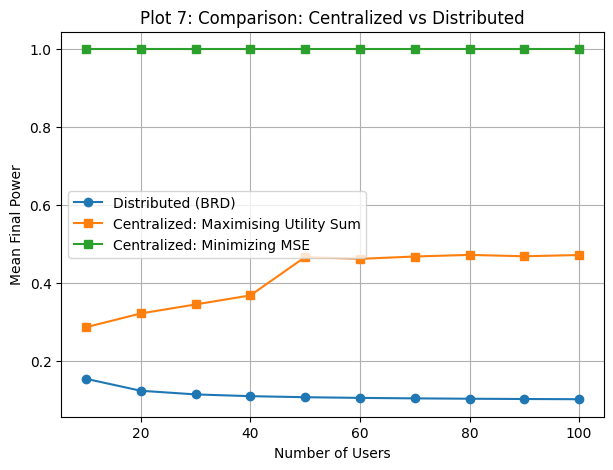

In [ ]:
brd_means = []
central_utl_means = []
central_mse_means = []
users_actual = []

for n in range(10, 101, 10):
    x_positions = np.linspace(d_max/n, d_max, n)
    transmitter_coordinates = [(x, 0.0, 0.0) for x in x_positions]

    h = np.zeros(n)
    for j in range(0,n):
        h[j] = get_channel_gain(transmitter_coordinates[j],receiver_coordinates,2405*10**6)
    P = np.random.uniform(0.1, 1.0, n)
    P_max = np.ones(n)

    # --- Distributed (your BRD) ---
    c_star, _, _, df, _, _ = adaptive_best_response(h, eta, epsilon, P_max, max_iteration)
    if df is not None and c_star is not None: # Check if both df and c_star are not None
        brd_means.append(df['Final Power P*'].mean())

    # --- Centralized Utility---
    P_central_utl = centralized_utility_solution(h, eta, c_star, P_max)
    central_utl_means.append(np.mean(P_central_utl))

    # --- Centralized MSE---
    P_central_mse = centralized_mse_solution(h, eta, P_max)
    central_mse_means.append(np.mean(P_central_mse))
    
    users_actual.append(n)


# --- Plot comparison ---
plt.figure(figsize=(7,5))

plt.plot(users_actual, brd_means, marker='o', label="Distributed (BRD)")
plt.plot(users_actual, central_utl_means, marker='s', label="Centralized: Maximising Utility Sum")
plt.plot(users_actual, central_mse_means, marker='s', label="Centralized: Minimizing MSE")
plt.xlabel("Number of Users")
plt.ylabel("Mean Final Power")
plt.title("Plot 7: Comparison: Centralized vs Distributed")
plt.legend()
plt.grid(True)
plt.show()

In [241]:
def mse_total(h, P, eta, sigma2=0.0):
    N = np.float64(len(h))
    return 1/np.power(N,2) * (np.sum(np.power(h*np.sqrt(P)/np.sqrt(eta) - 1.0, 2)) + (sigma2 / eta))

In [ ]:
import numpy as np

# show full precision
np.set_printoptions(precision=18, suppress=False, floatmode='maxprec', linewidth=200)

def as64(x):
    """Convert to float64 NumPy array without changing values."""
    return np.asarray(x, dtype=np.float64)

### (1/(MSExPxT)) efficiecy plot

In [254]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

time_brd = []
time_central_utl = []
time_central_mse = []

mse_brd = []
mse_central_utl = []
mse_central_mse = []

power_mean_brd = []
power_mean_central_utl = []
power_mean_central_mse = []

users_actual = []

for i in range(10, 101, 10):
    P = np.random.uniform(0.1, 1.0, i)
    P_max = np.ones(i)

    x_positions = np.linspace(d_max / i, d_max, i)
    transmitter_coordinates = [(x, 0.0, 0.0) for x in x_positions]

    h = [get_channel_gain(transmitter_coordinates[j], receiver_coordinates, 2405e6)
         for j in range(i)]
    
    # ---- BRD ----
    brd_result = adaptive_best_response(h, eta, epsilon, P_max, max_iteration)
    c_star, _, _, df, brd_time, _ = brd_result
    if df is None or brd_time is None or c_star is None:
        continue

    time_brd.append(brd_time / i)
    p_brd = df['Final Power P*'].values
    power_mean_brd.append(p_brd.mean())
    mse_brd.append(mse_total(h, p_brd, eta))


    # --- Centralized MSE ----
    t0 = time.time()
    p_central_mse = centralized_mse_solution(h, eta, P_max)
    t_mse = time.time() - t0

    time_central_mse.append(t_mse)
    power_mean_central_mse.append(float(np.mean(p_central_mse)))
    mse_central_mse.append(mse_total(h, p_central_mse, eta))


    # --- Centralized Utility ----
    t0 = time.time()
    p_central_utl = centralized_utility_solution(h, eta, c_star, P_max)
    cent_wall = time.time() - t0

    time_central_utl.append(cent_wall / i)

    power_mean_central_utl.append(np.mean(p_central_utl))
    mse_central_utl.append(mse_total(h, p_central_utl, eta))

    users_actual.append(i)

time_brd = np.array(time_brd)
time_central_utl = np.array(time_central_utl)
time_central_mse = np.array(time_central_mse)
mse_brd = np.array(mse_brd)
mse_central_utl = np.array(mse_central_utl)
mse_central_mse = np.array(mse_central_mse)
power_mean_brd = np.array(power_mean_brd)
power_mean_central_utl = np.array(power_mean_central_utl)
power_mean_central_mse = np.array(power_mean_central_mse)


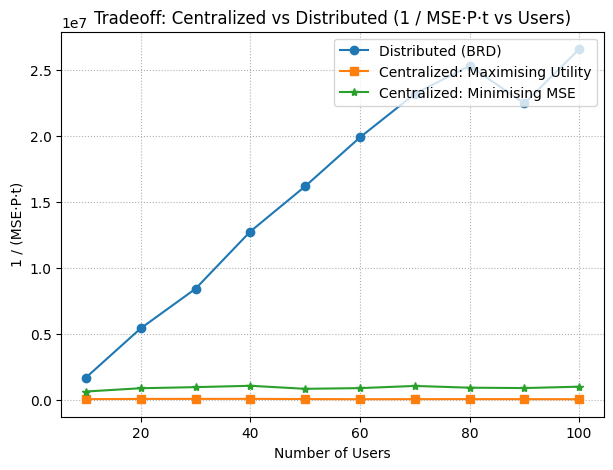

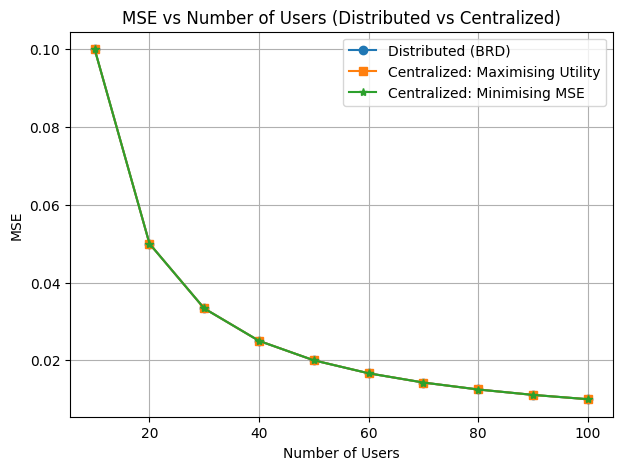

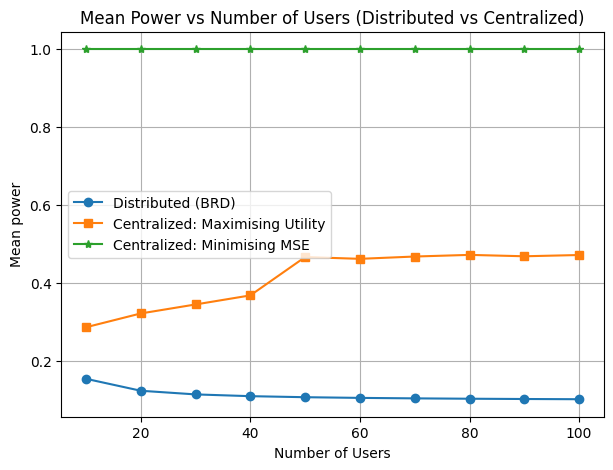

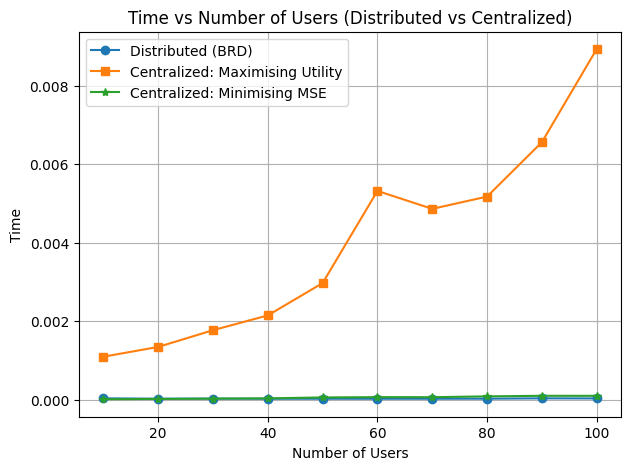

In [257]:
metric_brd = mse_brd * power_mean_brd * time_brd
metric_central_utl  = mse_central_utl * power_mean_central_utl * time_central_utl
metric_central_mse = mse_central_mse * power_mean_central_mse * time_central_mse

# ================== PLOT 1: tradeoff with inset zoom on Centralized ==================
fig, ax = plt.subplots(figsize=(7,5))

y_brd  = 1.0 / np.clip(metric_brd,     1e-30, None)
y_central_utl = 1.0 / np.clip(metric_central_utl, 1e-30, None)
y_central_mse = 1.0/np.clip(metric_central_mse , 1e-30, None)

ax.plot(users_actual, y_brd,  label="Distributed (BRD)", marker="o")
ax.plot(users_actual, y_central_utl, label="Centralized: Maximising Utility", marker="s")
ax.plot(users_actual, y_central_mse, label="Centralized: Minimising MSE", marker="*")
ax.set_xlabel("Number of Users")
ax.set_ylabel("1 / (MSE·P·t)")
ax.set_title("Tradeoff: Centralized vs Distributed (1 / MSE·P·t vs Users)")
ax.grid(True, ls=":")
ax.legend(loc="upper right")

plt.figure(figsize=(7,5))
plt.plot(users_actual, mse_brd,     label="Distributed (BRD)", marker="o")
plt.plot(users_actual, mse_central_utl, label="Centralized: Maximising Utility", marker="s")
plt.plot(users_actual, mse_central_mse, label="Centralized: Minimising MSE", marker="*")
plt.xlabel("Number of Users")
plt.ylabel("MSE")
plt.title("MSE vs Number of Users (Distributed vs Centralized)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))
plt.plot(users_actual, power_mean_brd,     label="Distributed (BRD)", marker="o")
plt.plot(users_actual, power_mean_central_utl, label="Centralized: Maximising Utility", marker="s")
plt.plot(users_actual, power_mean_central_mse, label="Centralized: Minimising MSE", marker="*")
plt.xlabel("Number of Users")
plt.ylabel("Mean power")
plt.title("Mean Power vs Number of Users (Distributed vs Centralized)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))
plt.plot(users_actual, time_brd,     label="Distributed (BRD)", marker="o")
plt.plot(users_actual, time_central_utl, label="Centralized: Maximising Utility", marker="s")
plt.plot(users_actual, time_central_mse, label="Centralized: Minimising MSE", marker="*")
plt.xlabel("Number of Users")
plt.ylabel("Time")
plt.title("Time vs Number of Users (Distributed vs Centralized)")
plt.legend()
plt.grid(True)
plt.show()

### Indoor/Outdoor Comparison

In [231]:
N = 10
x_positions = np.linspace(d_max/N, d_max, N)
transmitter_coordinates = [(x, 0.0, 0.0) for x in x_positions]

h_outdoor = np.zeros(N)
for i in range(N):
    h_outdoor[i] = get_channel_gain(transmitter_coordinates[i],receiver_coordinates,2405*10**6)

h_indoor = np.zeros(N)
for i in range(N):
    h_indoor[i] = get_channel_gain_InH(transmitter_coordinates[i],receiver_coordinates,2405*10**6)

P = np.random.uniform(0.1, 1.0, N)
P_max = np.ones(N)

c_star, utility_histories, power_histories, df_outdoor, brd_time, _ = adaptive_best_response(
        h_outdoor, eta, epsilon, P_max, max_iteration
    )

c_star, utility_histories, power_histories, df_indoor, brd_time, _ = adaptive_best_response(
        h_indoor, eta, epsilon, P_max, max_iteration
    )

10
10


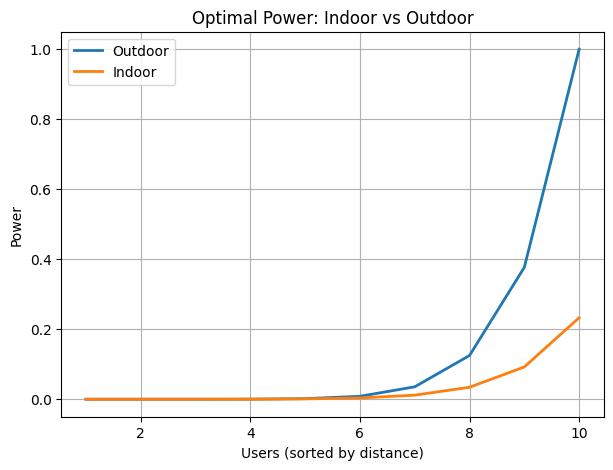

In [232]:
power_indoor = df_indoor['Final Power P*']   # your computed indoor power values
print(len(power_indoor))
power_outdoor = df_outdoor['Final Power P*']  # your computed outdoor power values
print(len(power_outdoor))

users = np.arange(1, len(power_indoor)+1)  # x-axis: user index (sorted)

plt.figure(figsize=(7,5))
plt.plot(users, power_outdoor, label="Outdoor", linewidth=2)
plt.plot(users, power_indoor, label="Indoor", linewidth=2)
plt.xlabel("Users (sorted by distance)")
plt.ylabel("Power")
plt.title("Optimal Power: Indoor vs Outdoor")
plt.grid(True)
plt.legend()
plt.show()